In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df = pd.read_csv('train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.shape

(891, 12)

### Why  Do EDA?
* Model building 
* Analysis and reporting 
* Handling missing values 
* feature engineering 
* Detecting Outliers

In [4]:
# Rembers it is an iterative process


### Columns Types 
* Numerical - > Age, Fare ,PassengerId
* Categorical -> Survived ,Pclass ,Sex SibSp , Parch,Embarked
* Mixed-Name ,Ticket , cabin

### Univariate Analysis

Univariate analysis focuses on analyzing each feature in the dataset independently.

* Distribution analysis: The distribution of each feature is examined to identify its shape, central tendency, and dispersion.

* Identifying potential issues: Univariate analysis helps in identifying potential problems with the data such as outliers, skewness, and missing values

The shape of a data distribution refers to its overall pattern or form as it is represented on a graph. Some common shapes of data distributions include:
Normal Distribution: A symmetrical and bell-shaped distribution where the mean, median, and mode are equal and the majority of the data falls in the middle of the distribution with gradually decreasing frequencies towards the tails.

* Skewed Distribution: A distribution that is not symmetrical, with one tail being longer than the other. It can be either positively skewed (right-skewed) or negatively skewed (left-skewed).

* Bimodal Distribution: A distribution with two peaks or modes.

* Uniform Distribution: A distribution where all values have an equal chance of occurring.

The shape of the data distribution is important in identifying the presence of outliers, skewness, and the type of statistical tests and models that can be used for further analysis.

Dispersion is a statistical term used to describe the spread or variability of a set of data. It measures how far the values in a data set are spread out from the central tendency (mean, median, or mode) of the data.
There are several measures of dispersion, including:

* Range: The difference between the largest and smallest values in a data set.

* Variance: The average of the squared deviations of each value from the mean of the data set.

* Standard Deviation: The square root of the variance. It provides a measure of the spread of the data that is in the same units as the original data.

* Interquartile range (IQR): The range between the first quartile (25th percentile) and the third quartile (75th percentile) of the data.

Dispersion helps to describe the spread of the data, which can help to identify the presence of outliers and skewness in the data.

### Steps of doing Univariate Analysis on Numerical columns

Descriptive Statistics: Compute basic summary statistics for the column, such as mean, median, mode, standard deviation, range, and quartiles. These statistics give a general understanding of the distribution of the data and can help identify skewness or outliers.

* Visualizations: Create visualizations to explore the distribution of the data. Some common visualizations for numerical data include histograms, box plots, and density plots. These visualizations provide a visual representation of the distribution of the data and can help identify skewness an outliers.

* Identifying Outliers: Identify and examine any outliers in the data. Outliers can be identified using visualizations. It is important to determine whether the outliers are due to measurement errors, data entry errors, or legitimate differences in the data, and to decide whether to include or exclude them from the analysis.

* Skewness: Check for skewness in the data and consider transforming the data or using robust statistical methods that are less sensitive to skewness, if necessary.

* Conclusion: Summarize the findings of the EDA and make decisions about how to proceed with further analysis.

### Age
conclusions

* Age is normally(almost) distributed
* 20% of the values are missing
* There are some outliers

In [5]:
df['Age'].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

<Axes: ylabel='Frequency'>

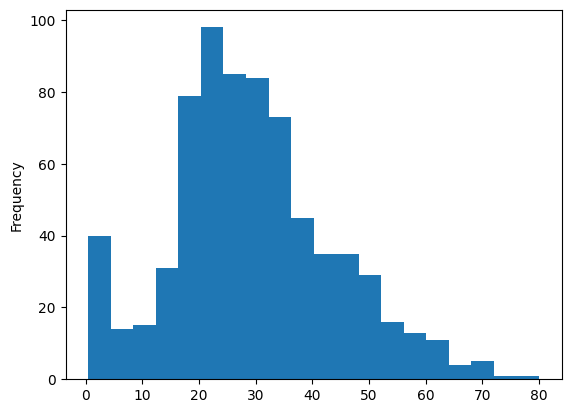

In [6]:
df['Age'].plot(kind='hist', bins=20)

<Axes: ylabel='Density'>

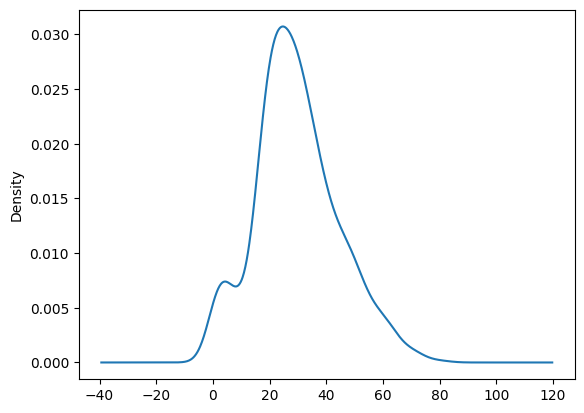

In [7]:
df['Age'].plot(kind='kde')

<Axes: xlabel='Age', ylabel='Count'>

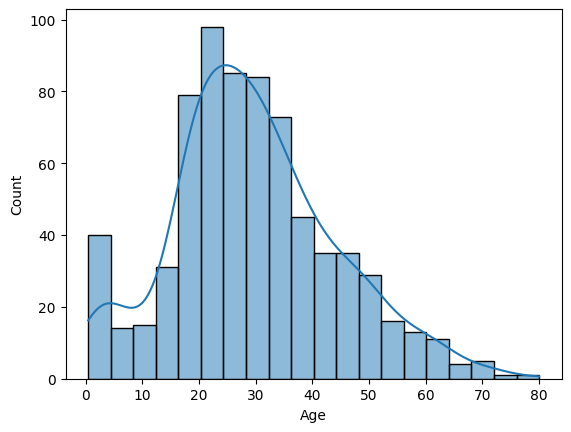

In [8]:

sns.histplot(df['Age'], kde=True, bins=20)


In [9]:
df['Age'].skew()

np.float64(0.38910778230082704)

<Axes: >

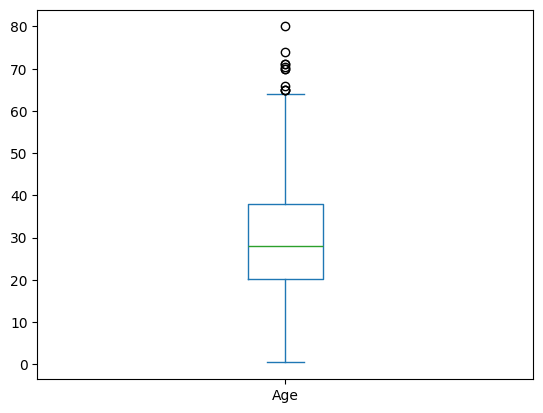

In [10]:
df['Age'].plot(kind='box')

In [11]:
df[df['Age']>65]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
33,34,0,2,"Wheadon, Mr. Edward H",male,66.0,0,0,C.A. 24579,10.5000,NaN,S
96,97,0,1,"Goldschmidt, Mr. George B",male,71.0,0,0,PC 17754,34.6542,A5,C
116,117,0,3,"Connors, Mr. Patrick",male,70.5,0,0,370369,7.7500,NaN,Q
493,494,0,1,"Artagaveytia, Mr. Ramon",male,71.0,0,0,PC 17609,49.5042,NaN,C
630,631,1,1,"Barkworth, Mr. Algernon Henry Wilson",male,80.0,0,0,27042,30.0000,A23,S
672,673,0,2,"Mitchell, Mr. Henry Michael",male,70.0,0,0,C.A. 24580,10.5000,NaN,S
745,746,0,1,"Crosby, Capt. Edward Gifford",male,70.0,1,1,WE/P 5735,71.0000,B22,S
851,852,0,3,"Svensson, Mr. Johan",male,74.0,0,0,347060,7.7750,NaN,S


In [12]:
df[df['Age']>65].count()

PassengerId    8
Survived       8
Pclass         8
Name           8
Sex            8
Age            8
SibSp          8
Parch          8
Ticket         8
Fare           8
Cabin          3
Embarked       8
dtype: int64

In [13]:
df[(df['Age'] > 65) & (df['Age'] < 25)]


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


In [18]:
round(df['Age'].isnull().sum()/ len(df['Age'])*100,3)

np.float64(19.865)

### Fare Columns

* conclusion

1. The data is highley(positive) skew
2. Fare col actually contain the group fare and not the indivivdual fare (the might be issue)
3.  we need to create new col called individual fare

In [15]:
df['Fare'].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

<Axes: ylabel='Density'>

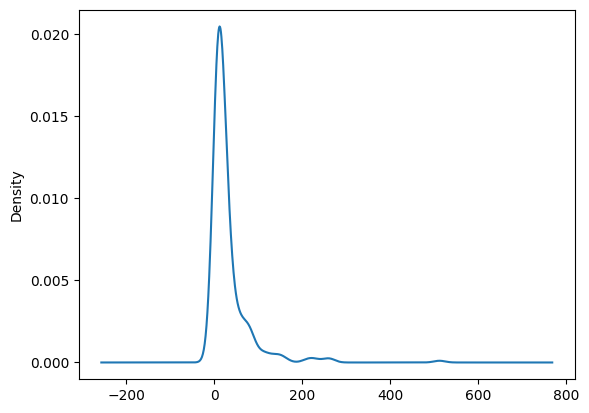

In [19]:
df['Fare'].plot(kind='kde')

<Axes: ylabel='Frequency'>

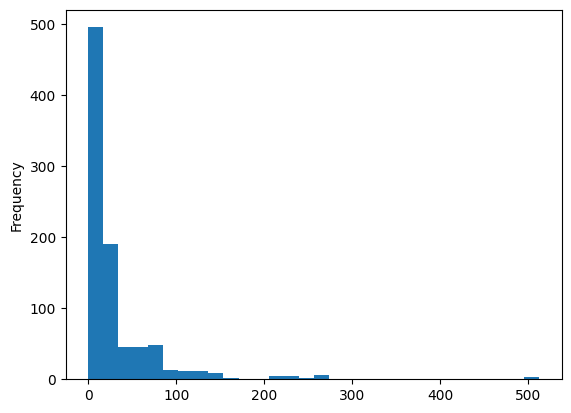

In [20]:
df['Fare'].plot(kind='hist', bins=30)

In [21]:
df['Fare'].skew()

np.float64(4.787316519674893)

<Axes: >

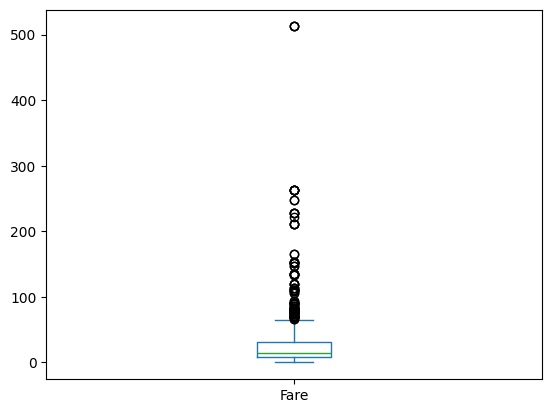

In [22]:
df['Fare'].plot(kind='box')

In [26]:
df[df['Fare'] >250]


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.0000,C23 C25 C27,S
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.0,3,2,19950,263.0000,C23 C25 C27,S
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C
311,312,1,1,"Ryerson, Miss. Emily Borie",female,18.0,2,2,PC 17608,262.3750,B57 B59 B63 B66,C
341,342,1,1,"Fortune, Miss. Alice Elizabeth",female,24.0,3,2,19950,263.0000,C23 C25 C27,S
438,439,0,1,"Fortune, Mr. Mark",male,64.0,1,4,19950,263.0000,C23 C25 C27,S
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C
742,743,1,1,"Ryerson, Miss. Susan Parker ""Suzette""",female,21.0,2,2,PC 17608,262.3750,B57 B59 B63 B66,C


In [33]:

df['Fare'].isnull().sum()

np.int64(0)

### Survived
**conclusions**

* Parch and SibSp cols can be merged to form a new col call family_size
* Create a new col called is_alone

<Axes: xlabel='Survived'>

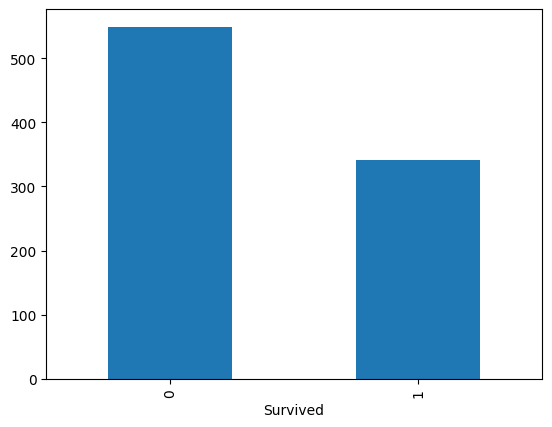

In [35]:
df['Survived'].value_counts().plot(kind='bar')

<Axes: >

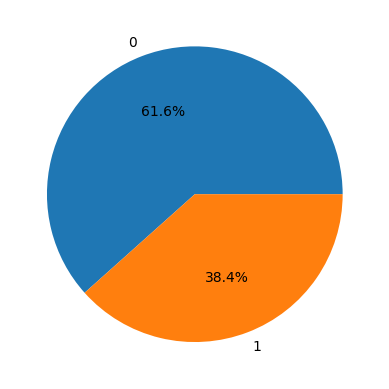

In [ ]:
df['Survived'].value_counts().plot(kind='pie',autopct='%0.1f%%')  # 0 means died people -> 1 isn live the titanic

In [38]:
df['Survived'].isnull().sum()

np.int64(0)

### PClass
**Concluasion**


In [39]:
df['Pclass'].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

<Axes: ylabel='Pclass'>

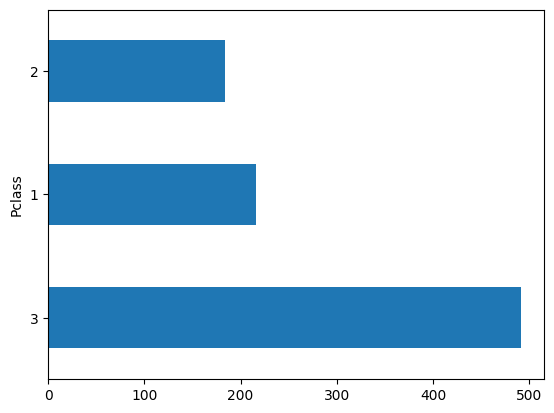

In [42]:
df['Pclass'].value_counts().plot(kind='barh')

<Axes: >

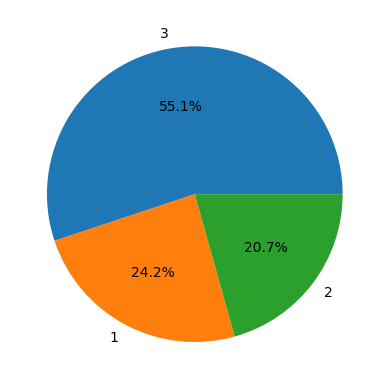

In [41]:
df['Pclass'].value_counts().plot(kind='pie',autopct='%0.1f%%')

In [44]:
df['Pclass'].isnull().sum()


np.int64(0)

### Sex
**Conclusion**


In [45]:
df['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

<Axes: xlabel='Sex'>

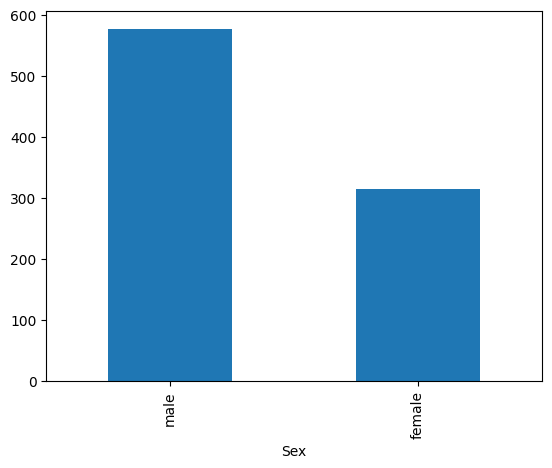

In [49]:
df['Sex'].value_counts().plot(kind='bar')

<Axes: >

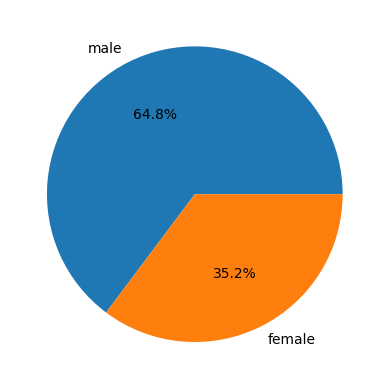

In [47]:
df['Sex'].value_counts().plot(kind='pie',autopct='%0.1f%%')

In [46]:
df['Sex'].isnull().sum()


np.int64(0)

### SibSp
**Conclusion**

In [53]:
df['SibSp'].head(3)

0    1
1    1
2    0
Name: SibSp, dtype: int64

In [50]:
df['SibSp'].value_counts()

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

<Axes: >

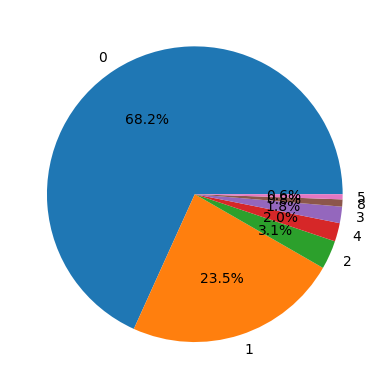

In [54]:
df['SibSp'].value_counts().plot(kind='pie',autopct='%0.1f%%')

<Axes: xlabel='SibSp'>

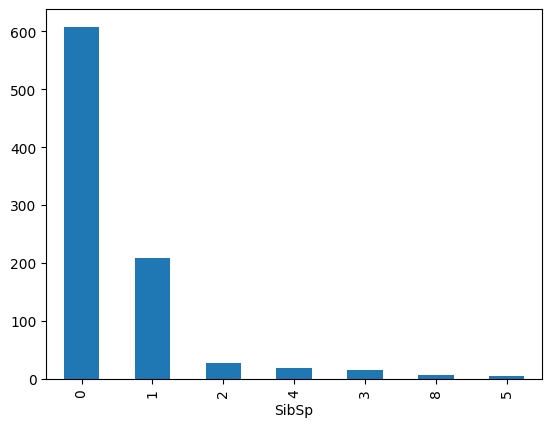

In [55]:
df['SibSp'].value_counts().plot(kind='bar')

In [56]:
df['SibSp'].isnull().sum()

np.int64(0)

### Parch
**Conclion**

* Parch and SoibSp cl be merged to form a new col famkily size
* create a new col called is_alone

In [59]:
df['Parch'].value_counts()

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64

<Axes: >

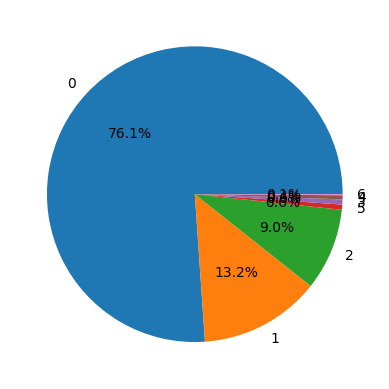

In [58]:
df['Parch'].value_counts().plot(kind='pie',autopct='%0.1f%%')

<Axes: xlabel='Parch'>

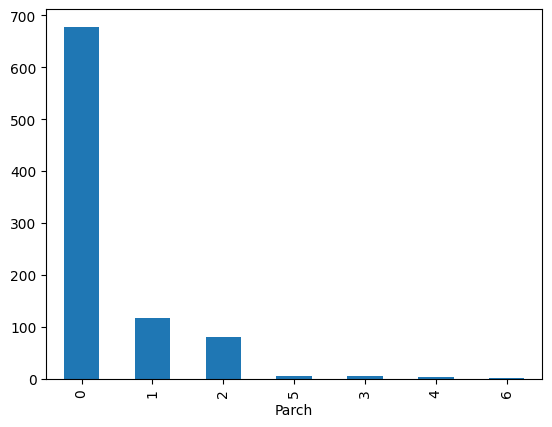

In [57]:
df['Parch'].value_counts().plot(kind='bar')

In [60]:
df['Parch'].isnull().sum()

np.int64(0)

### Embarked 
**Conclusion**


In [61]:
df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

<Axes: xlabel='Embarked'>

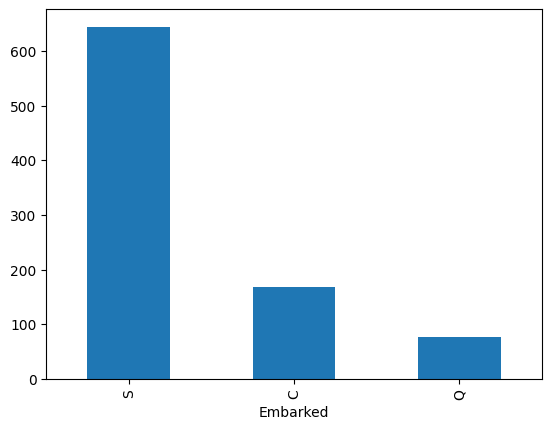

In [62]:
df['Embarked'].value_counts().plot(kind='bar')

<Axes: >

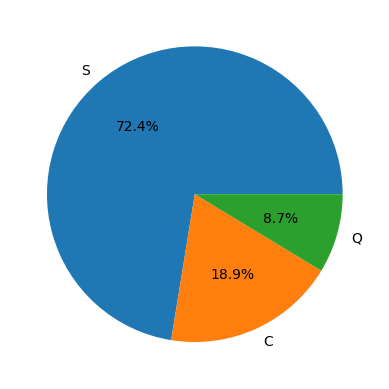

In [63]:
df['Embarked'].value_counts().plot(kind='pie',autopct='%0.1f%%')

In [64]:
df['Embarked'].isnull().sum()

np.int64(2)

### Steps of doing Bivariate Analysis
* Select 2 cols

* Understand type of relationship

1. Numerical - Numerical
a. You can plot graphs like scatterplot(regression plots), 2D histplot, 2D KDEplots

b. Check correlation coefficent to check linear relationship

2. Numerical - Categorical - create visualizations that compare the           distribution of the numerical data across different categories of the categorical data.

a. You can plot graphs like barplot, boxplot, kdeplot violinplot even scatterplots

3. Categorical - Categorical

a. You can create cross-tabulations or contingency tables that show the distribution of values in one categorical column, grouped by the values in the other categorical column.

b. You can plots like heatmap, stacked barplots, treemaps

* Write your conclusions

In [66]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<Axes: xlabel='Pclass', ylabel='Survived'>

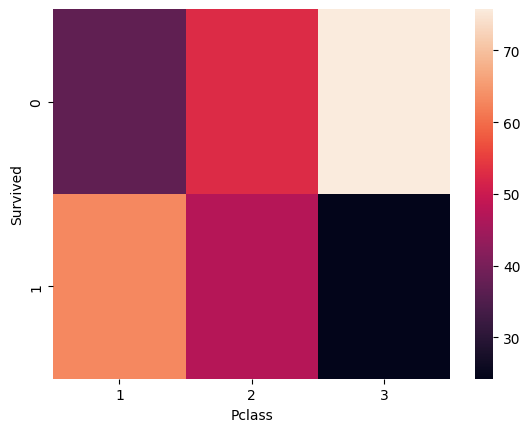

In [70]:
sns.heatmap(pd.crosstab(df['Survived'], df['Pclass'], normalize='columns')*100)

In [69]:
pd.crosstab(df['Survived'], df['Pclass'], normalize='index')

Pclass,1,2,3
Survived,,,
0,0.145719,0.176685,0.677596
1,0.397661,0.254386,0.347953


In [72]:
pd.crosstab(df['Survived'], df['Sex'], normalize='columns')*100

Sex,female,male
Survived,,
0,25.796178,81.109185
1,74.203822,18.890815


In [73]:
pd.crosstab(df['Survived'], df['Embarked'], normalize='columns')*100

Embarked,C,Q,S
Survived,,,
0,44.642857,61.038961,66.304348
1,55.357143,38.961039,33.695652


In [74]:
pd.crosstab(df['Sex'], df['Embarked'], normalize='columns')*100

Embarked,C,Q,S
Sex,,,
female,43.452381,46.753247,31.521739
male,56.547619,53.246753,68.478261


In [75]:
pd.crosstab(df['Pclass'], df['Embarked'], normalize='columns')*100

Embarked,C,Q,S
Pclass,,,
1,50.595238,2.597403,19.720497
2,10.119048,3.896104,25.465839
3,39.285714,93.506494,54.813665
